In [ ]:
import scanpy as sc

## Pre-processing

In [2]:
# !mkdir data
# !wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
# !cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz

In [ ]:
markers = {'Memory CD4 T': ['IL7R', 'CD3D', 'CD3E'], 'Naive CD4 T': ['IL7R', 'CCR7', 'CD3D', 'CD3E'],  
            'CD8 T': ['CD8B', 'CCL5', 'CD2', 'CD3D', 'CD3E'], 
           'NK': ['GNLY', 'NKG7'], 
           'B': ['MS4A1', 'CD79A'], 
           'CD14+ Mono': ['CD14', 'LYZ'],  'FCGR3A+ Mono': ['FCGR3A', 'MS4A7'],  'DC': ['FCER1A', 'CST3', 'CD74'], 
           'Platelet': ['PPBP', 'PF4']}

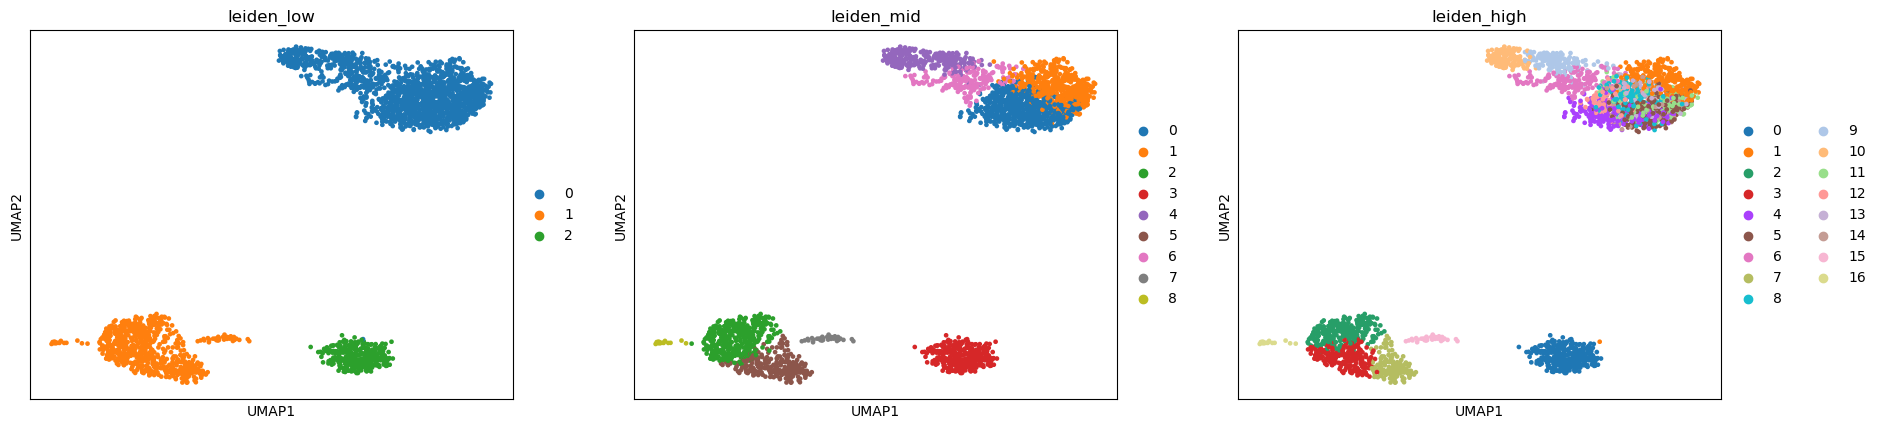

In [ ]:
import numpy as np
adata = sc.read_10x_mtx(
    './data/filtered_gene_bc_matrices/hg19/',  # the directory with the `.mtx` file
    var_names='gene_symbols',                  # use gene symbols for the variable names (variables-axis index)
    cache=True)   

adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
mito_genes = adata.var_names.str.startswith('MT-')
# for each cell compute fraction of counts in mito genes vs. all genes
# the `.A1` is only necessary as X is sparse (to transform to a dense array after summing)
adata.obs['percent_mito'] = np.sum(
    adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
# add the total counts per cell as observations-annotation to adata
adata.obs['n_counts'] = adata.X.sum(axis=1)
adata = adata[adata.obs.n_genes < 2500, :]
adata = adata[adata.obs.percent_mito < 0.05, :]
sc.pp.normalize_total(adata, target_sum=1e4)
adata_norm = adata.copy()
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added='leiden_low', resolution=.1)
sc.tl.leiden(adata, key_added='leiden_mid', resolution=1.2)
sc.tl.leiden(adata, key_added='leiden_high', resolution=2.)
sc.pl.umap(adata, color=['leiden_low', 'leiden_mid', 'leiden_high'])
adata_norm.obs['leiden_low'] = adata.obs['leiden_low']
adata_norm.obs['leiden_mid'] = adata.obs['leiden_mid']
adata_norm.obs['leiden_high'] = adata.obs['leiden_high']

In [19]:
# Assign the mid clusters to the cell types
adata.obs['cell_type'] = adata.obs['leiden_mid'].map({'0': 'Naive CD4 T', '1': 'Memory CD4 T', '2': 'FCGR3A+ Mono', '3': 'B', '4': 'NK', '5': 'CD14+ Mono', '6': 'CD8 T', '7': 'DC', '8': 'Platelet'})
adata_norm.obs['cell_type'] = adata.obs['cell_type']

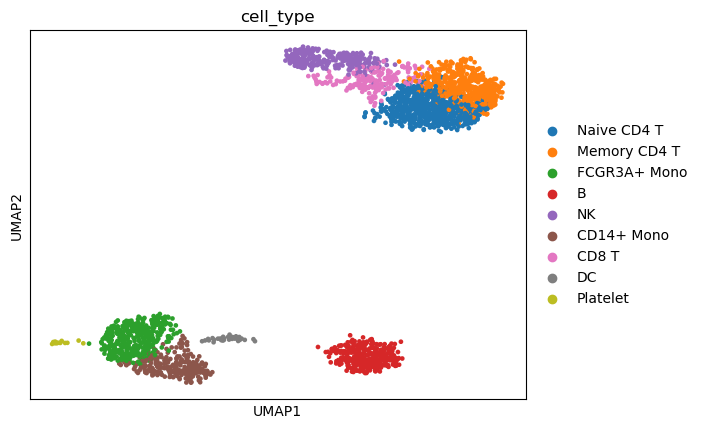

In [48]:
sc.pl.umap(adata, color=['cell_type'])


In [11]:
import importlib
import os

file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
scanpy_wrapper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scanpy_wrapper)

In [44]:
top_genes = 10

# For each cluster in leiden_low, get the LN signatures
low_clusters = adata_norm.obs['leiden_low'].unique()
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_low")
ln_low_signatures = dict(zip(low_clusters, 
                                    [sc.get.rank_genes_groups_df(adata_norm, group=c)[:top_genes]['names'].tolist() for c in low_clusters]))

# For each cluster in leiden_low, get the LN signatures
mid_clusters = adata_norm.obs['leiden_mid'].unique()
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_mid")
ln_mid_signatures = dict(zip(mid_clusters, 
                                    [sc.get.rank_genes_groups_df(adata_norm, group=c)[:top_genes]['names'].tolist() for c in mid_clusters]))              


# For each cluster in leiden_low, get the LN signatures
high_clusters = adata_norm.obs['leiden_high'].unique()
scanpy_wrapper.rank_genes_groups_ln(adata_norm, "leiden_high")
ln_high_signatures = dict(zip(high_clusters, 
                                    [sc.get.rank_genes_groups_df(adata_norm, group=c)[:top_genes]['names'].tolist() for c in high_clusters]))              



Processing group: 0
Processing group: 1
Processing group: 2
Processing group: 0
Processing group: 1
Processing group: 2
Processing group: 3
Processing group: 4
Processing group: 5
Processing group: 6
Processing group: 7
Processing group: 8
Processing group: 0
Processing group: 1
Processing group: 2
Processing group: 3
Processing group: 4
Processing group: 5
Processing group: 6
Processing group: 7
Processing group: 8
Processing group: 9
Processing group: 10
Processing group: 11
Processing group: 12
Processing group: 13
Processing group: 14
Processing group: 15
Processing group: 16


In [45]:
top_genes = 10

# For each cluster in leiden_low, get the LN signatures
low_clusters = adata.obs['leiden_low'].unique()
sc.tl.rank_genes_groups(adata, "leiden_low")
log1p_low_signatures = dict(zip(low_clusters, 
                                    [sc.get.rank_genes_groups_df(adata, group=c)[:top_genes]['names'].tolist() for c in low_clusters]))

# For each cluster in leiden_low, get the LN signatures
mid_clusters = adata.obs['leiden_mid'].unique()
sc.tl.rank_genes_groups(adata, "leiden_mid")
log1p_mid_signatures = dict(zip(mid_clusters, 
                                    [sc.get.rank_genes_groups_df(adata, group=c)[:top_genes]['names'].tolist() for c in mid_clusters]))              


# For each cluster in leiden_low, get the LN signatures
high_clusters = adata.obs['leiden_high'].unique()
sc.tl.rank_genes_groups(adata, "leiden_high")
log1p_high_signatures = dict(zip(high_clusters, 
                                    [sc.get.rank_genes_groups_df(adata, group=c)[:top_genes]['names'].tolist() for c in high_clusters]))              



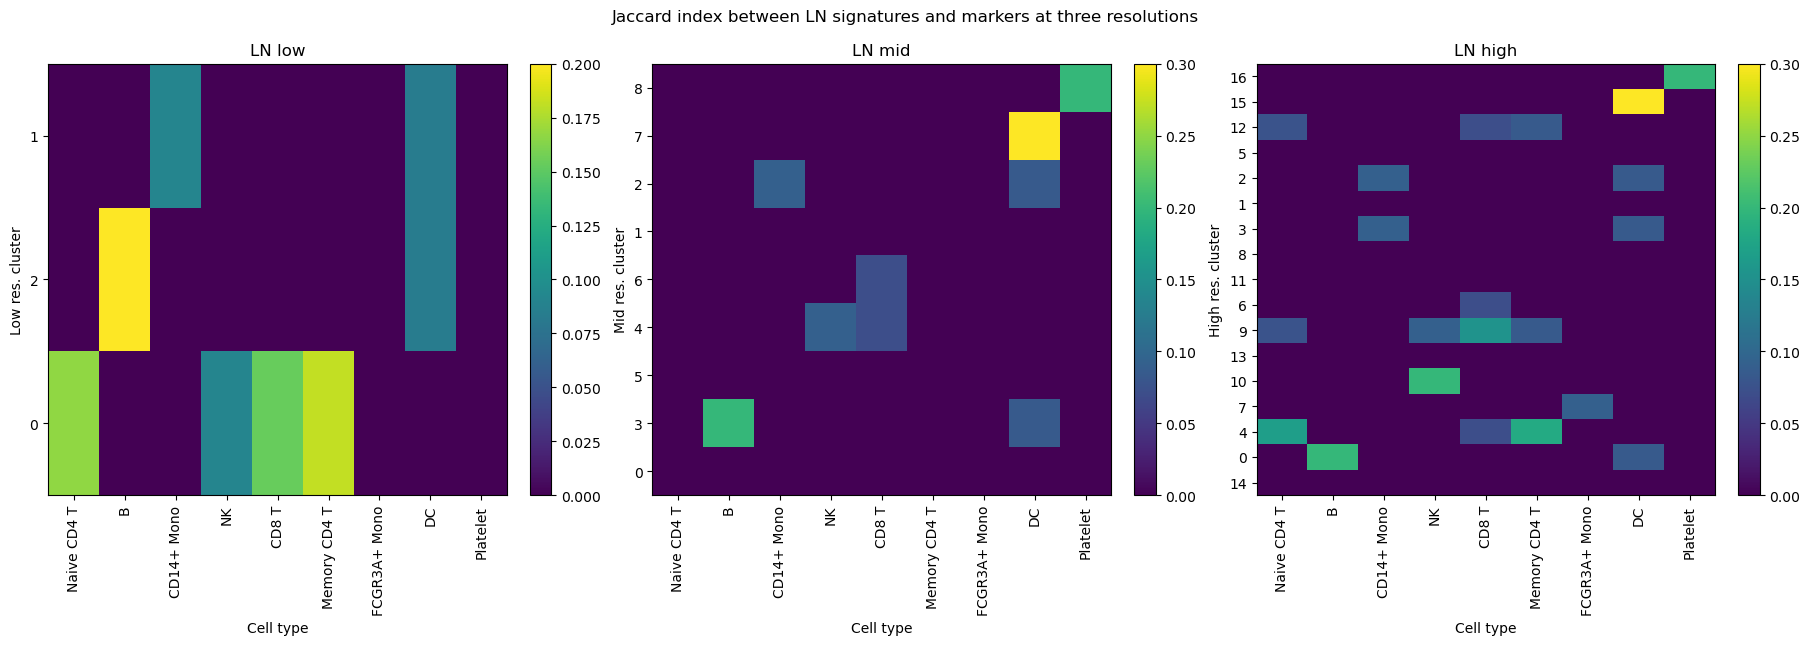

In [47]:
import numpy as np

def compute_jaccard_index(signature_1, signature_2):
    """
    Compute the Jaccard index between two signatures.
    """
    return len(set(signature_1) & set(signature_2)) / len(set(signature_1) | set(signature_2))

cell_types = adata_norm.obs['cell_type'].unique()

# Compute LN low matrix
ln_low_mat = np.zeros((len(low_clusters), len(cell_types)))
for i, c in enumerate(low_clusters):
    for j, c2 in enumerate(cell_types):
        ln_low_mat[i, j] = compute_jaccard_index(ln_low_signatures[c], markers[c2])

# Compute LN mid matrix
ln_mid_mat = np.zeros((len(mid_clusters), len(cell_types)))
for i, c in enumerate(mid_clusters):
    for j, c2 in enumerate(cell_types):
        ln_mid_mat[i, j] = compute_jaccard_index(ln_mid_signatures[c], markers[c2])

# Compute LN high matrix
ln_high_mat = np.zeros((len(high_clusters), len(cell_types)))
for i, c in enumerate(high_clusters):
    for j, c2 in enumerate(cell_types):
        ln_high_mat[i, j] = compute_jaccard_index(ln_high_signatures[c], markers[c2])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Plot for ln_low_mat
c1 = axes[0].pcolormesh(ln_low_mat)
axes[0].set_xticks(np.arange(ln_low_mat.shape[1]) + 0.5, minor=False)
axes[0].set_yticks(np.arange(ln_low_mat.shape[0]) + 0.5, minor=False)
axes[0].set_xticklabels(cell_types, rotation=90)
axes[0].set_yticklabels(low_clusters)
fig.colorbar(c1, ax=axes[0])
axes[0].set_title('LN low')
axes[0].set_xlabel('Cell type')
axes[0].set_ylabel('Low res. cluster')

# Plot for ln_mid_mat
c2 = axes[1].pcolormesh(ln_mid_mat)
axes[1].set_xticks(np.arange(ln_mid_mat.shape[1]) + 0.5, minor=False)
axes[1].set_yticks(np.arange(ln_mid_mat.shape[0]) + 0.5, minor=False)
axes[1].set_xticklabels(cell_types, rotation=90)
axes[1].set_yticklabels(mid_clusters)
fig.colorbar(c2, ax=axes[1])
axes[1].set_title('LN mid')
axes[1].set_xlabel('Cell type')
axes[1].set_ylabel('Mid res. cluster')

# Plot for ln_high_mat
c3 = axes[2].pcolormesh(ln_high_mat)
axes[2].set_xticks(np.arange(ln_high_mat.shape[1]) + 0.5, minor=False)
axes[2].set_yticks(np.arange(ln_high_mat.shape[0]) + 0.5, minor=False)
axes[2].set_xticklabels(cell_types, rotation=90)
axes[2].set_yticklabels(high_clusters)
fig.colorbar(c3, ax=axes[2])
axes[2].set_title('LN high')
axes[2].set_xlabel('Cell type')
axes[2].set_ylabel('High res. cluster')

plt.suptitle('Jaccard index between LN signatures and markers at three resolutions', y=1.05)
plt.show()


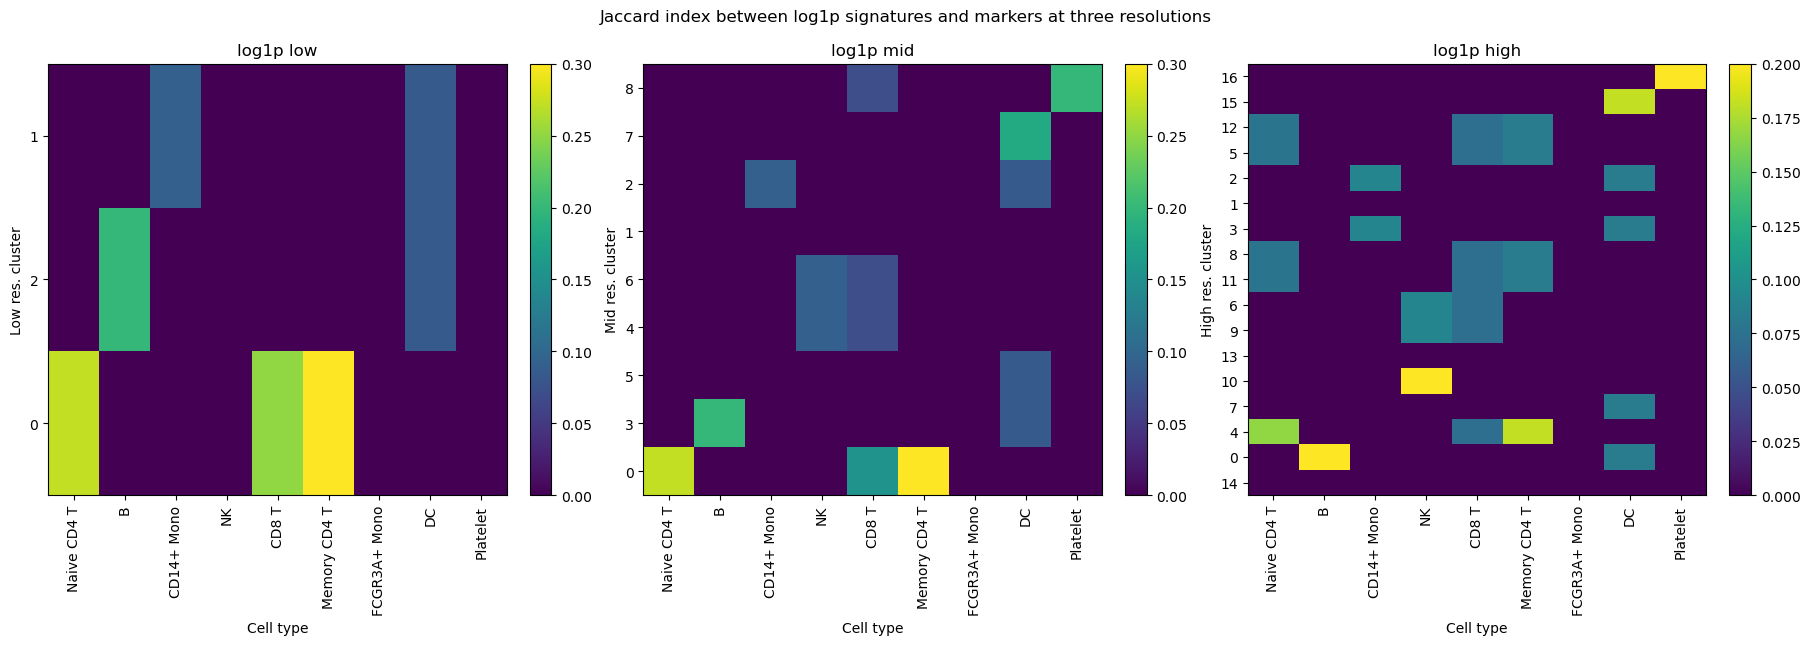

In [ ]:
cell_types = adata_norm.obs['cell_type'].unique()

# Compute LN low matrix
log1p_low_mat = np.zeros((len(low_clusters), len(cell_types)))
for i, c in enumerate(low_clusters):
    for j, c2 in enumerate(cell_types):
        log1p_low_mat[i, j] = compute_jaccard_index(log1p_low_signatures[c], markers[c2])

# Compute LN mid matrix
log1p_mid_mat = np.zeros((len(mid_clusters), len(cell_types)))
for i, c in enumerate(mid_clusters):
    for j, c2 in enumerate(cell_types):
        log1p_mid_mat[i, j] = compute_jaccard_index(log1p_mid_signatures[c], markers[c2])

# Compute LN high matrix
log1p_high_mat = np.zeros((len(high_clusters), len(cell_types)))
for i, c in enumerate(high_clusters):
    for j, c2 in enumerate(cell_types):
        log1p_high_mat[i, j] = compute_jaccard_index(log1p_high_signatures[c], markers[c2])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Plot for ln_low_mat
c1 = axes[0].pcolormesh(log1p_low_mat)
axes[0].set_xticks(np.arange(log1p_low_mat.shape[1]) + 0.5, minor=False)
axes[0].set_yticks(np.arange(log1p_low_mat.shape[0]) + 0.5, minor=False)
axes[0].set_xticklabels(cell_types, rotation=90)
axes[0].set_yticklabels(low_clusters)
fig.colorbar(c1, ax=axes[0])
axes[0].set_title('log1p low')
axes[0].set_xlabel('Cell type')
axes[0].set_ylabel('Low res. cluster')

# Plot for ln_mid_mat
c2 = axes[1].pcolormesh(log1p_mid_mat)
axes[1].set_xticks(np.arange(log1p_mid_mat.shape[1]) + 0.5, minor=False)
axes[1].set_yticks(np.arange(log1p_mid_mat.shape[0]) + 0.5, minor=False)
axes[1].set_xticklabels(cell_types, rotation=90)
axes[1].set_yticklabels(mid_clusters)
fig.colorbar(c2, ax=axes[1])
axes[1].set_title('log1p mid')
axes[1].set_xlabel('Cell type')
axes[1].set_ylabel('Mid res. cluster')

# Plot for ln_high_mat
c3 = axes[2].pcolormesh(log1p_high_mat)
axes[2].set_xticks(np.arange(log1p_high_mat.shape[1]) + 0.5, minor=False)
axes[2].set_yticks(np.arange(log1p_high_mat.shape[0]) + 0.5, minor=False)
axes[2].set_xticklabels(cell_types, rotation=90)
axes[2].set_yticklabels(high_clusters)
fig.colorbar(c3, ax=axes[2])
axes[2].set_title('log1p high')
axes[2].set_xlabel('Cell type')
axes[2].set_ylabel('High res. cluster')

plt.suptitle('Jaccard index between log1p signatures and markers at three resolutions', y=1.05)
plt.show()
